<a href="https://colab.research.google.com/github/LesTa98/northstar-data-analysis/blob/main/notebooks/01_python_pandas_numpy_cleaning_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style="whitegrid")


In [ ]:
deliveries = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/deliveries.csv")
orders = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/orders.csv")
customers = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/customers.csv")
drivers = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/drivers.csv")
vehicles = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/vehicles.csv")
hubs = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/hubs.csv")
complaints = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/complaints.csv")
incidents = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/incidents.csv")
app_events = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/app_events.csv")

The code below loops through all datasets and checks their size, missing values, and duplicate rows to understand the data quality before cleaning it.

In [ ]:
datasets = {
    "deliveries": deliveries,
    "orders": orders,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events
}

for name, df in datasets.items():
  print("DATASET:", name)
  print("SHAPE:", df.shape)
  print("NULLS: \n", df.isnull().sum())
  print("DUPLICATES:", df.duplicated().sum())
  print("-------------\n")

DATASET: deliveries
SHAPE: (950, 13)
NULLS: 
 delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64
DUPLICATES: 0
-------------

DATASET: orders
SHAPE: (1250, 11)
NULLS: 
 order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64
DUPLICATES: 0
-------------

DATASET: customers
SHAPE: (650, 9)
NULLS: 
 custome

The code below standardises the column names across all datasets

In [ ]:
def clean_cols(df):
  df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
  return df

for key in datasets:
  datasets[key] = clean_cols(datasets[key])

deliveries = datasets["deliveries"]
orders = datasets["orders"]
customers = datasets["customers"]
drivers = datasets["drivers"]
vehicles = datasets["vehicles"]
hubs = datasets["hubs"]
complaints = datasets["complaints"]
incidents = datasets["incidents"]
app_events = datasets["app_events"]

The code below fixes the data types in the tables for analysis.

Deliveries Table:


In [ ]:
#datetime columns
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors="coerce").dt.floor("s")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce").dt.floor("s")

#numeric columns
deliveries["route_distance_km"] = pd.to_numeric(deliveries["route_distance_km"], errors="coerce").round(2)
deliveries["manual_route_override_count"] = pd.to_numeric(deliveries["manual_route_override_count"], errors="coerce")
deliveries["proof_of_completion_missing"] = pd.to_numeric(deliveries["proof_of_completion_missing"], errors="coerce")
deliveries["customer_rating_post_delivery"] = pd.to_numeric(deliveries["customer_rating_post_delivery"], errors="coerce").round(2)
deliveries["fuel_or_charge_cost"] = pd.to_numeric(deliveries["fuel_or_charge_cost"], errors="coerce").round(2)

#convert delivery_status to category
deliveries["delivery_status"] = deliveries["delivery_status"].astype("category")

deliveries.info()
deliveries.head()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   delivery_id                    950 non-null    object        
 1   order_id                       950 non-null    object        
 2   driver_id                      950 non-null    object        
 3   vehicle_id                     950 non-null    object        
 4   hub_id                         950 non-null    object        
 5   dispatch_time                  950 non-null    datetime64[ns]
 6   delivery_completed_at          931 non-null    datetime64[ns]
 7   delivery_status                950 non-null    category      
 8   route_distance_km              950 non-null    float64       
 9   manual_route_override_count    950 non-null    int64         
 10  proof_of_completion_missing    950 non-null    int64         
 11  customer_rating_pos

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22


Orders Table:


In [ ]:
# datetime column
orders["order_created_at"] = pd.to_datetime(orders['order_created_at'], errors="coerce").dt.floor("s")

# numeric columns
orders["promised_window_hours"] = pd.to_numeric(orders["promised_window_hours"], errors="coerce")
orders["order_vlaue"] = pd.to_numeric(orders["order_value"],errors="coerce").round(2)
orders["special_handling_flag"] = pd.to_numeric(orders["special_handling_flag"], errors="coerce")

# categorical columns
categorical_cols = ["service_type", "pickup_zone", "dropoff_zone", "priority_level", "booking_channel"]
for col in categorical_cols:
   orders[col] = orders[col].astype("category")

orders.info()
orders.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               1250 non-null   object        
 1   customer_id            1250 non-null   object        
 2   service_type           1250 non-null   category      
 3   order_created_at       1250 non-null   datetime64[ns]
 4   promised_window_hours  1250 non-null   int64         
 5   pickup_zone            1250 non-null   category      
 6   dropoff_zone           1250 non-null   category      
 7   priority_level         1250 non-null   category      
 8   order_value            1250 non-null   float64       
 9   booking_channel        1225 non-null   category      
 10  special_handling_flag  1250 non-null   int64         
 11  order_vlaue            1250 non-null   float64       
dtypes: category(5), datetime64[ns](1), float64(2), int64(2), objec

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,order_vlaue
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0,126.65
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0,109.30
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0,33.50
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1,10.04
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0,125.58


Customers Table:

In [ ]:
# datetime column
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce").dt.floor("s")

# numeric columns
customers["age"] = pd.to_numeric(customers["age"], errors="coerce")
customers["loyalty_score"] = pd.to_numeric(customers["loyalty_score"], errors="coerce").round(2)
customers["app_engagement_score"] = pd.to_numeric(customers["app_engagement_score"], errors="coerce").round(2)

# categorical columns
categorical_cols = ["home_zone", "customer_type", "preferred_channel", "account_status"]
for col in categorical_cols:
    customers[col] = customers[col].astype("category")

customers.info()
customers.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           650 non-null    object        
 1   age                   650 non-null    int64         
 2   home_zone             650 non-null    category      
 3   customer_type         650 non-null    category      
 4   signup_date           650 non-null    datetime64[ns]
 5   loyalty_score         630 non-null    float64       
 6   app_engagement_score  650 non-null    float64       
 7   preferred_channel     637 non-null    category      
 8   account_status        650 non-null    category      
dtypes: category(4), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 29.2+ KB


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


Drivers Table:

In [ ]:
# numeric columns
drivers["years_experience"] = pd.to_numeric(drivers["years_experience"], errors="coerce")
drivers["training_score"] = pd.to_numeric(drivers["training_score"], errors="coerce").round(2)
drivers["driver_rating"] = pd.to_numeric(drivers["driver_rating"], errors="coerce").round(2)
drivers["active_flag"] = pd.to_numeric(drivers["active_flag"], errors="coerce").astype("int")

# categorical columns
categorical_cols = ["base_zone", "employment_type", "shift_preference"]
for col in categorical_cols:
    drivers[col] = drivers[col].astype("category")

drivers.info()
drivers.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   driver_id         170 non-null    object  
 1   base_zone         170 non-null    category
 2   employment_type   170 non-null    category
 3   years_experience  170 non-null    int64   
 4   training_score    163 non-null    float64 
 5   driver_rating     170 non-null    float64 
 6   shift_preference  170 non-null    category
 7   active_flag       170 non-null    int64   
dtypes: category(3), float64(2), int64(2), object(1)
memory usage: 8.3+ KB


,driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag
0,D001,AIRPORT,FullTime,8,67.8,3.54,Morning,1
1,D002,Central,FullTime,4,42.4,3.94,Evening,1
2,D003,AIRPORT,FullTime,11,96.5,5.00,Evening,1
3,D004,Airport,PartTime,13,88.9,4.75,Morning,1
4,D005,north,FullTime,3,69.7,4.14,Morning,1


Vehicles Table:


In [ ]:
# datetime column
vehicles["commission_date"] = pd.to_datetime(vehicles["commission_date"], errors="coerce").dt.floor("s")

# numeric columns
vehicles["battery_health_pct"] = pd.to_numeric(vehicles["battery_health_pct"], errors="coerce").round(2)
vehicles["odometer_km"] = pd.to_numeric(vehicles["odometer_km"], errors="coerce")

# categorical columns
categorical_cols = ["vehicle_type", "assigned_zone", "maintenance_status", "telematics_version"]
for col in categorical_cols:
    vehicles[col] = vehicles[col].astype("category")

vehicles.info()
vehicles.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   vehicle_id          120 non-null    object        
 1   vehicle_type        120 non-null    category      
 2   assigned_zone       120 non-null    category      
 3   commission_date     120 non-null    datetime64[ns]
 4   battery_health_pct  116 non-null    float64       
 5   odometer_km         120 non-null    int64         
 6   maintenance_status  120 non-null    category      
 7   telematics_version  120 non-null    category      
dtypes: category(4), datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 5.5+ KB


,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,V001,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
1,V002,EV,AIRPORT,2024-04-21 16:14:00,67.9,159368,InRepair,v2.2
2,V003,CargoVan,north,2025-11-24 23:59:00,91.7,219359,Active,v2.1
3,V004,Hybrid,RiverSide,2024-06-07 13:21:00,NaN,36310,Active,v2.2
4,V005,CargoVan,West,2025-11-15 11:08:00,58.6,146638,Active,v2.2


Hubs Table:

In [ ]:
# numeric columns
hubs["capacity_score"] = pd.to_numeric(hubs["capacity_score"], errors="coerce").round(2)

# categorical columns
categorical_cols = [ "zone", "hub_type"]
for col in categorical_cols:
  hubs[col] = hubs[col].astype("category")

hubs.info()
hubs.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   hub_id          8 non-null      object  
 1   hub_name        8 non-null      object  
 2   zone            8 non-null      category
 3   hub_type        8 non-null      category
 4   capacity_score  8 non-null      int64   
dtypes: category(2), int64(1), object(2)
memory usage: 900.0+ bytes


,hub_id,hub_name,zone,hub_type,capacity_score
0,H01,North Exchange,North,Dispatch,82
1,H02,South Link,South,Dispatch,78
2,H03,East Dock,East,Warehouse,74
3,H04,West Gate,West,Dispatch,69
4,H05,Central Core,Central,Control,88


Complaints Table:


In [ ]:
# datetime column
complaints["created_at"] = pd.to_datetime(complaints["created_at"], errors="coerce").dt.floor("s")

#numerical columns
complaints["resolution_days"] = pd.to_numeric(complaints["resolution_days"],errors="coerce")
complaints["compensation_amount"] = pd.to_numeric(complaints["compensation_amount"], errors="coerce").round(2)

#catergorical columms
categorical_cols = ["complaint_type", "channel", "severity", "status"]
for col in categorical_cols:
  complaints[col] = complaints[col].astype("category")

complaints.info()
complaints.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   complaint_id         320 non-null    object        
 1   customer_id          320 non-null    object        
 2   order_id             320 non-null    object        
 3   complaint_type       320 non-null    category      
 4   channel              320 non-null    category      
 5   severity             320 non-null    category      
 6   created_at           320 non-null    datetime64[ns]
 7   status               320 non-null    category      
 8   resolution_days      320 non-null    int64         
 9   compensation_amount  304 non-null    float64       
dtypes: category(4), datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 17.3+ KB


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


Incidents Table:

In [ ]:
#datetime column
incidents["reported_at"] = pd.to_datetime(incidents["reported_at"], errors="coerce").dt.floor("s")

#numerical column
incidents["resolved_hours"] = pd.to_numeric(incidents["resolved_hours"], errors="coerce")

#catergorical columms
categorical_cols = ["incident_type", "severity", "resolution_status"]
for col in categorical_cols:
  incidents[col] = incidents[col].astype("category")

incidents.info()
incidents.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   incident_id        280 non-null    object        
 1   delivery_id        280 non-null    object        
 2   incident_type      280 non-null    category      
 3   reported_at        280 non-null    datetime64[ns]
 4   severity           280 non-null    category      
 5   resolution_status  280 non-null    category      
 6   resolved_hours     263 non-null    float64       
dtypes: category(3), datetime64[ns](1), float64(1), object(2)
memory usage: 10.5+ KB


,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0
3,I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8
4,I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0


App Events Table:


In [ ]:
#datetime column
app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"], errors="coerce").dt.floor("s")

#numerical column
app_events["api_latency_ms"] = pd.to_numeric(app_events["api_latency_ms"], errors="coerce")
app_events["success_flag"] = pd.to_numeric(app_events["success_flag"],errors="coerce")

#catergorical columms
categorical_cols = ["event_type", "device_type", "zone_context"]
for col in categorical_cols:
    app_events[col] = app_events[col].astype("category")

app_events.info()
app_events.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   event_id         640 non-null    object        
 1   customer_id      640 non-null    object        
 2   order_id         496 non-null    object        
 3   event_timestamp  640 non-null    datetime64[ns]
 4   event_type       640 non-null    category      
 5   session_id       640 non-null    object        
 6   device_type      640 non-null    category      
 7   zone_context     640 non-null    category      
 8   api_latency_ms   640 non-null    int64         
 9   success_flag     640 non-null    int64         
dtypes: category(3), datetime64[ns](1), int64(2), object(4)
memory usage: 38.2+ KB


,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
0,AE00001,C0488,NaN,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
1,AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
2,AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1
3,AE00004,C0407,O00756,2025-08-23 17:38:00,eta_refresh,S41236,iOS,CENTRAL,442,1
4,AE00005,C0506,NaN,2024-05-29 10:33:00,search_route,S12030,iOS,north,60,1


The code below fixes the missing values in the tables.

In [ ]:
def handle_missing(df, numeric_fill="median", categorical_fill="Unknown"):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            # Numeric
            if pd.api.types.is_numeric_dtype(df[col]):
                if numeric_fill == "median":
                    df[col] = df[col].fillna(df[col].median())
                else:
                    df[col] = df[col].fillna(numeric_fill)

            # Categorical / object
            elif pd.api.types.is_categorical_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
                if pd.api.types.is_categorical_dtype(df[col]):
                    if categorical_fill not in df[col].cat.categories:
                        df[col] = df[col].cat.add_categories(categorical_fill)
                df[col] = df[col].fillna(categorical_fill)

            # Datetime
            elif pd.api.types.is_datetime64_any_dtype(df[col]):
                df[col] = df[col].fillna(df[col].min())
    return df


for name, df in datasets.items():
  datasets[name] = handle_missing(df)

# the "False" output from the function below proves all the missing values have handled
for name, df in datasets.items():
  print(f"{name} has NaNs? {df.isnull().values.any()}")

deliveries has NaNs? False
orders has NaNs? False
customers has NaNs? False
drivers has NaNs? False
vehicles has NaNs? False
hubs has NaNs? False
complaints has NaNs? False
incidents has NaNs? False
app_events has NaNs? False


/tmp/ipykernel_10780/3989886929.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
/tmp/ipykernel_10780/3989886929.py:13: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[col]):


The code below removes invalid values in the tables

In [ ]:
def fix_invalid_values(all_tables):
    for name, df in all_tables.items():

        # numeric fix
        for col in df.select_dtypes(include=["number"]).columns:
            if (df[col] < 0).any():
                median_val = df[col][df[col] >= 0].median()
                df[col] = df[col].mask(df[col] < 0, median_val)

        # Table specific fixes

        if name == "deliveries":
            # Ratings 0-5
            if "customer_rating_post_delivery" in df.columns:
                df["customer_rating_post_delivery"] = df["customer_rating_post_delivery"].clip(0, 5)
            # Ensure delivery_completed_at >= dispatch_time
            if "delivery_completed_at" in df.columns and "dispatch_time" in df.columns:
                invalid_mask = df["delivery_completed_at"] < df["dispatch_time"]
                df.loc[invalid_mask, "delivery_completed_at"] = df.loc[invalid_mask, "dispatch_time"]

        if name == "orders":
            if "promised_window_hours" in df.columns:
                df["promised_window_hours"] = df["promised_window_hours"].clip(lower=1)

        if name == "complaints":
            for col in ["resolution_days", "compensation_amount"]:
                if col in df.columns:
                    df[col] = df[col].mask(df[col] < 0, df[col].median())

        if name == "app_events":
            if "api_latency_ms" in df.columns:
                df["api_latency_ms"] = df["api_latency_ms"].mask(df["api_latency_ms"] < 0, df["api_latency_ms"].median())

        if name == "vehicles":
            for col in ["battery_health_pct", "odometer_km"]:
                if col in df.columns:
                    df[col] = df[col].mask(df[col] < 0, df[col].median())

        all_tables[name] = df

    return all_tables



datasets = fix_invalid_values(datasets)

#print each table's shape and whether any missing values remain
for name, df in datasets.items():
    print(f"{name} shape: {df.shape}, NaNs? {df.isnull().values.any()}")


deliveries shape: (950, 13), NaNs? False
orders shape: (1250, 12), NaNs? False
customers shape: (650, 9), NaNs? False
drivers shape: (170, 8), NaNs? False
vehicles shape: (120, 8), NaNs? False
hubs shape: (8, 5), NaNs? False
complaints shape: (320, 10), NaNs? False
incidents shape: (280, 7), NaNs? False
app_events shape: (640, 10), NaNs? False


The code below removes duplicates from all the tables:

In [ ]:
for name, df in datasets.items():
  before = df.shape[0]
  datasets[name] = df.drop_duplicates()
  after = df.shape[0]
  print(f"{name}: {before} → {after} rows (duplicates removed: {before - after})")

deliveries: 950 → 950 rows (duplicates removed: 0)
orders: 1250 → 1250 rows (duplicates removed: 0)
customers: 650 → 650 rows (duplicates removed: 0)
drivers: 170 → 170 rows (duplicates removed: 0)
vehicles: 120 → 120 rows (duplicates removed: 0)
hubs: 8 → 8 rows (duplicates removed: 0)
complaints: 320 → 320 rows (duplicates removed: 0)
incidents: 280 → 280 rows (duplicates removed: 0)
app_events: 640 → 640 rows (duplicates removed: 0)


The code below merges all the tables in one master table:

In [ ]:
def merge_all_tables(all_tables):
    df = datasets["deliveries"].copy()

    # ---------------- PRIMARY MERGES ----------------
    merge_order = ["orders", "customers", "drivers", "vehicles", "hubs"]
    merge_keys = {
        "orders": "order_id",
        "customers": "customer_id",
        "drivers": "driver_id",
        "vehicles": "vehicle_id",
        "hubs": "hub_id"
    }

    for table in merge_order:
        if table in datasets:
            key = merge_keys[table]
            df = df.merge(datasets[table], on=key, how="left")

    complaints_df = all_tables["complaints"].copy()
    complaints_df["has_complaint"] = 1

    complaints_flag = complaints_df.groupby("order_id")["has_complaint"].max().reset_index()

    df = df.merge(complaints_flag, on="order_id", how="left")
    df["has_complaint"] = df["has_complaint"].fillna(0)

    complaint_count = complaints_df.groupby("order_id").size().reset_index(name="complaint_count")
    df = df.merge(complaint_count, on="order_id", how="left")
    df["complaint_count"] = df["complaint_count"].fillna(0)

    incidents_df = all_tables["incidents"].copy()
    incidents_df["has_incident"] = 1

    incident_flag = incidents_df.groupby("delivery_id")["has_incident"].max().reset_index()

    df = df.merge(incident_flag, on="delivery_id", how="left")
    df["has_incident"] = df["has_incident"].fillna(0)


    incident_count = incidents_df.groupby("delivery_id").size().reset_index(name="incident_count")
    df = df.merge(incident_count, on="delivery_id", how="left")
    df["incident_count"] = df["incident_count"].fillna(0)

    return df

master_df = merge_all_tables(datasets)
master_df["pickup_zone"] = master_df["pickup_zone"].str.strip().str.title()
master_df["dropoff_zone"] = master_df["dropoff_zone"].str.strip().str.title()
master_df["assigned_zone"] = master_df["assigned_zone"].str.strip().str.title()
master_df["base_zone"] = master_df["base_zone"].str.strip().str.title()
master_df["home_zone"] = master_df["home_zone"].str.strip().str.title()

print(master_df.shape)


(950, 54)


The code below calculates delivery delays and basic statistics:

In [ ]:


# Calculate delay in minutes
master_df["delay_minutes"] = (
    (master_df["delivery_completed_at"] - master_df["dispatch_time"])
    .dt.total_seconds() / 60
)

delay_arr = master_df["delay_minutes"].to_numpy()

mean_delay = np.mean(delay_arr)
median_delay = np.median(delay_arr)
std_delay = np.std(delay_arr)
percentiles = np.percentile(delay_arr, [25, 50, 75, 90, 95])

print(f"Mean delay (minutes): {mean_delay:.2f}")
print(f"Median delay (minutes): {median_delay:.2f}")
print(f"Standard deviation: {std_delay:.2f}")
print(f"Percentiles [25,50,75,90,95]: {percentiles}")

Mean delay (minutes): 564.94
Median delay (minutes): 393.69
Standard deviation: 515.37
Percentiles [25,50,75,90,95]: [ 167.20416667  393.69166667  859.65       1330.85833333 1477.05833333]


PYTHON ANALYSIS QUERIES

In [ ]:
master_df["risk_score"] = (
    master_df["incident_count"] * 2 +
    master_df["complaint_count"] * 1.5 +
    master_df["has_incident"] * 3
)

Delivery Duration

In [ ]:
master_df['delivery_duration'] = (master_df['delivery_completed_at'] - master_df['dispatch_time']).dt.total_seconds() / 60

1. Hub Summary

Shows total deliveries, average delay, and complaints for each hub.

In [ ]:
hub_summary = master_df.groupby('hub_name').agg({
    'delivery_id': 'count',
    'delay_minutes': 'mean',
    'has_complaint': 'sum'
}).rename(columns={
    'delivery_id': 'total_deliveries',
    'delay_minutes': 'avg_delay',
    'has_complaint': 'complaints'
}).reset_index()
hub_summary["complaints"] = hub_summary["complaints"].astype(int)
hub_summary = hub_summary.sort_values(by="total_deliveries")
print(hub_summary)


         hub_name  total_deliveries   avg_delay  complaints
0     Airport Hub               104  543.544071          21
6      South Link               106  520.440723          16
5   Riverside Hub               115  593.666812          30
1    Central Core               115  650.995652          28
2       East Dock               119  455.213305          31
7       West Gate               127  608.451575          26
3   Midtown Relay               128  584.119141          31
4  North Exchange               136  556.239583          26


2. Driver Summary

Displays total deliveries, average rating, average delay, and incidents for each driver.

In [ ]:
driver_summary = master_df.groupby('driver_id').agg({
    'delivery_id': 'count',
    'customer_rating_post_delivery': 'mean',
    'delay_minutes': 'mean',
    'incident_count': 'sum'
}).rename(columns={
    'delivery_id': 'total_deliveries',
    'customer_rating_post_delivery': 'avg_customer_rating',
    'delay_minutes': 'avg_delay'
}).reset_index()
driver_summary['avg_customer_rating'] = driver_summary['avg_customer_rating'].round(2)
driver_summary["incident_count"] = driver_summary["incident_count"].astype(int)
driver_summary['avg_delay'] = driver_summary['avg_delay'].round(2)
driver_summary = driver_summary.sort_values(by="total_deliveries")
print(driver_summary)

    driver_id  total_deliveries  avg_customer_rating  avg_delay  \
28       D029                 1                 3.98     139.88   
58       D059                 1                 5.00     235.92   
65       D066                 1                 4.56     255.48   
20       D021                 2                 3.10      77.37   
39       D040                 2                 4.22    1124.62   
..        ...               ...                  ...        ...   
107      D108                11                 4.41     482.98   
86       D087                12                 3.82     541.82   
118      D119                12                 4.03     564.18   
132      D133                12                 3.42     603.73   
101      D102                13                 4.14     367.01   

     incident_count  
28                0  
58                0  
65                1  
20                1  
39                0  
..              ...  
107               4  
86                6

3. Vehicle Summary

Summarises deliveries, fuel cost, odometer usage, and battery health for each vehicle.

In [ ]:
vehicle_summary = master_df.groupby(['vehicle_id','vehicle_type']).agg({
    'delivery_id': 'count',
    'fuel_or_charge_cost': 'mean',
    'odometer_km': 'mean',
    'battery_health_pct': 'mean'
}).rename(columns={
    'delivery_id': 'total_deliveries',
    'fuel_or_charge_cost': 'avg_fuel_cost',
    'odometer_km': 'avg_odometer',
    'battery_health_pct': 'avg_battery_health'
}).reset_index()
vehicle_summary['avg_fuel_cost'] = vehicle_summary['avg_fuel_cost'].round(2)
print(vehicle_summary)

    vehicle_id vehicle_type  total_deliveries  avg_fuel_cost  avg_odometer  \
0         V001     CargoVan                 0            NaN           NaN   
1         V001       Diesel                 0            NaN           NaN   
2         V001           EV                10          12.94       56928.0   
3         V001       Hybrid                 0            NaN           NaN   
4         V002     CargoVan                 0            NaN           NaN   
..         ...          ...               ...            ...           ...   
475       V119       Hybrid                 0            NaN           NaN   
476       V120     CargoVan                 0            NaN           NaN   
477       V120       Diesel                 0            NaN           NaN   
478       V120           EV                11          14.37      192246.0   
479       V120       Hybrid                 0            NaN           NaN   

     avg_battery_health  
0                   NaN  
1          

/tmp/ipykernel_10780/3666295734.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vehicle_summary = master_df.groupby(['vehicle_id','vehicle_type']).agg({


4. Customer Summary

Provides total orders, average order value, and complaints for each customer.

In [ ]:
customer_summary = master_df.groupby(['customer_id','customer_type']).agg({
    'order_id': 'count',
    'order_value': 'mean',
    'has_complaint': 'sum'
}).rename(columns={
    'order_id': 'total_orders',
    'order_value': 'avg_order_value',
    'has_complaint': 'complaints'
}).reset_index()
customer_summary["complaints"] = customer_summary["complaints"].astype(int)
print(customer_summary)

     customer_id customer_type  total_orders  avg_order_value  complaints
0          C0001      Consumer             0              NaN           0
1          C0001    Enterprise             0              NaN           0
2          C0001           SME             2           130.72           2
3          C0002      Consumer             1           135.53           0
4          C0002    Enterprise             0              NaN           0
...          ...           ...           ...              ...         ...
1543       C0649    Enterprise             3           112.10           1
1544       C0649           SME             0              NaN           0
1545       C0650      Consumer             1            84.48           0
1546       C0650    Enterprise             0              NaN           0
1547       C0650           SME             0              NaN           0

[1548 rows x 5 columns]


/tmp/ipykernel_10780/658086641.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_summary = master_df.groupby(['customer_id','customer_type']).agg({


5. Risk Summary

 Shows average delay, risk score, and complaints for each priority level.

In [ ]:
risk_summary = master_df.groupby('priority_level').agg({
    'delay_minutes': 'mean',
    'risk_score': 'mean',
    'has_complaint': 'sum'
}).rename(columns={
    'delay_minutes': 'avg_delay',
    'risk_score': 'avg_risk',
    'has_complaint': 'complaints'
}).reset_index()
risk_summary["complaints"] = risk_summary["complaints"].astype(int)
risk_summary['avg_delay'] = risk_summary['avg_delay'].round(2)
risk_summary['avg_risk'] = risk_summary['avg_risk'].round(2)
print(risk_summary)

  priority_level  avg_delay  avg_risk  complaints
0       Critical     435.58      1.66          18
1           High     596.06      1.89          51
2            Low     534.23      1.58          54
3         Medium     591.71      1.77          86


/tmp/ipykernel_10780/839635429.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_summary = master_df.groupby('priority_level').agg({


6. Correlation

Measures the relationship between delays and complaints, and delays and customer ratings.

In [ ]:
corr_delay_complaint = master_df['delay_minutes'].corr(master_df['has_complaint'])
corr_delay_rating = master_df['delay_minutes'].corr(master_df['customer_rating_post_delivery'])
print(corr_delay_complaint)
print(corr_delay_rating)

0.024755844563017004
-0.2937619843414302


7. Top 10 Orders

Identifies the top 10 highest-value orders.

In [ ]:
top_orders = master_df.nlargest(10, 'order_value')[['order_id','order_value','customer_id']]
print(top_orders)

    order_id  order_value customer_id
624   O00980       510.06       C0545
818   O00892       326.38       C0157
11    O01207       321.68       C0197
235   O00013       302.70       C0234
414   O01145       301.38       C0548
238   O00052       293.65       C0150
795   O00860       292.33       C0076
871   O00144       288.86       C0063
124   O00472       287.30       C0636
487   O01053       285.05       C0106


8. Avg Delivery Duration by Service

Calculates the average delivery duration for each service type.

In [ ]:
service_duration = master_df.groupby('service_type')['delivery_duration'].mean().reset_index()
service_duration['delivery_duration'] = service_duration['delivery_duration'].round(2)
print(service_duration)

  service_type  delivery_duration
0     Business             545.64
1      Medical             587.25
2       Parcel             577.02
3    Passenger             541.44
4       Retail             580.11


/tmp/ipykernel_10780/1635436378.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  service_duration = master_df.groupby('service_type')['delivery_duration'].mean().reset_index()


9. Deliveries per Vehicle Type per Zone

Counts deliveries for each vehicle type in each assigned zone.

In [ ]:
vehicle_zone_summary = master_df.groupby(['vehicle_type','assigned_zone'])['delivery_id'].count().reset_index(name='total_deliveries')
print(vehicle_zone_summary)

   vehicle_type assigned_zone  total_deliveries
0      CargoVan       Airport                14
1      CargoVan       Central                28
2      CargoVan           Ctr                 5
3      CargoVan          East                31
4      CargoVan         North                69
5      CargoVan     Riverside                18
6      CargoVan         South                25
7      CargoVan          West                33
8        Diesel       Airport                24
9        Diesel       Central                23
10       Diesel           Ctr                 0
11       Diesel          East                14
12       Diesel         North                21
13       Diesel     Riverside                15
14       Diesel         South                28
15       Diesel          West                19
16           EV       Airport                34
17           EV       Central                52
18           EV           Ctr                38
19           EV          East           

/tmp/ipykernel_10780/2548352123.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vehicle_zone_summary = master_df.groupby(['vehicle_type','assigned_zone'])['delivery_id'].count().reset_index(name='total_deliveries')


10. Complaints by Channel

Shows total complaints for each booking channel.

In [ ]:
complaints_channel = master_df.groupby('booking_channel')['has_complaint'].sum().reset_index()
complaints_channel['has_complaint'] = complaints_channel['has_complaint'].astype(int)
print(complaints_channel)

  booking_channel  has_complaint
0             API             12
1             App            114
2           Phone             34
3             Web             42
4         Unknown              7


/tmp/ipykernel_10780/3953937159.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  complaints_channel = master_df.groupby('booking_channel')['has_complaint'].sum().reset_index()


11. Age vs Risk

Displays average customer age and risk score by customer type.

In [ ]:
age_risk_summary = master_df.groupby('customer_type')[['age','risk_score']].mean().reset_index()
age_risk_summary['age'] = age_risk_summary['age'].round(2)
age_risk_summary['risk_score'] = age_risk_summary['risk_score'].round(2)
print(age_risk_summary)

  customer_type    age  risk_score
0      Consumer  46.50        1.77
1    Enterprise  44.51        1.74
2           SME  47.29        1.61


/tmp/ipykernel_10780/945397593.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_risk_summary = master_df.groupby('customer_type')[['age','risk_score']].mean().reset_index()


12. Delay Flag Counts

Counts how many deliveries are delayed versus on-time.

In [ ]:
master_df['delay_flag'] = np.where(master_df['delay_minutes'] > 0, 'Delayed', 'OnTime')
delay_flag_summary = master_df['delay_flag'].value_counts().reset_index()
delay_flag_summary.columns = ['delay_flag','count']
print(delay_flag_summary)

  delay_flag  count
0    Delayed    867
1     OnTime     83


13. Worst Performing Hubs

Ranks worst performing hubs based on average delay and also shows the complaint and incident counts.

In [61]:
master_df["has_complaint"] = (master_df["complaint_count"] > 0).astype(int)
master_df["incident_count"] = (master_df["incident_count"] > 0).astype(int)
worst_hubs = master_df.groupby("hub_name").agg({
    "delay_minutes": "mean",
    "has_complaint": "sum",
    "incident_count": "sum"
}).rename(columns={
    "delay_minutes": "avg_delay",
    "has_complaint": "total_complaints",
    "incident_count": "total_incidents"
}).sort_values(by="avg_delay", ascending=False)

print(worst_hubs)

                 avg_delay  total_complaints  total_incidents
hub_name                                                     
Central Core    650.995652                28               34
West Gate       608.451575                26               33
Riverside Hub   593.666812                30               32
Midtown Relay   584.119141                31               32
North Exchange  556.239583                26               30
Airport Hub     543.544071                21               25
South Link      520.440723                16               30
East Dock       455.213305                31               32


14. Vehicle Battery Health vs Delivery delay impact Analysis

This query examines whether lower vehicle battery health is associated with higher delivery delays, helping identify if poor vehicle condition negatively impacts delivery performance.



In [67]:
battery_impact = master_df.groupby("vehicle_id").agg({
    "battery_health_pct": "mean",
    "delay_minutes": "mean",
    "delivery_id": "count"
}).reset_index()

battery_impact = battery_impact.rename(columns={
    "battery_health_pct": "avg_battery_health",
    "delay_minutes": "avg_delay",
    "delivery_id": "total_deliveries"
})

print(battery_impact.sort_values("avg_battery_health"))

    vehicle_id  avg_battery_health   avg_delay  total_deliveries
24        V025                42.0  631.002778                 6
83        V084                47.6  654.578571                 7
86        V087                49.7  512.013333                 5
9         V010                50.7  407.457143                 7
107       V108                54.6  835.150000                 9
..         ...                 ...         ...               ...
67        V068                97.5  302.916667                 8
13        V014               100.0  587.885714                 7
79        V080               100.0  614.914286                 7
78        V079               100.0  560.183333                 8
102       V103               100.0  739.258333                 8

[120 rows x 4 columns]


Python Visuals

1. Delivery Status by Priority Level

Shows how delivery outcomes (e.g., completed, delayed) vary across different priority levels.

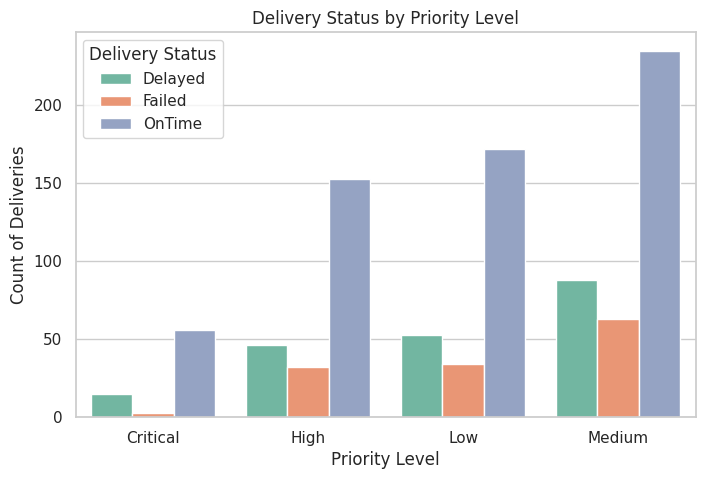

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=master_df, x='priority_level', hue='delivery_status', palette='Set2')
plt.title("Delivery Status by Priority Level")
plt.xlabel("Priority Level")
plt.ylabel("Count of Deliveries")
plt.legend(title="Delivery Status")
plt.show()

2. Delivery Delays by Hub (Boxplot)

Displays the distribution and variability of delivery delays for each hub, highlighting outliers.

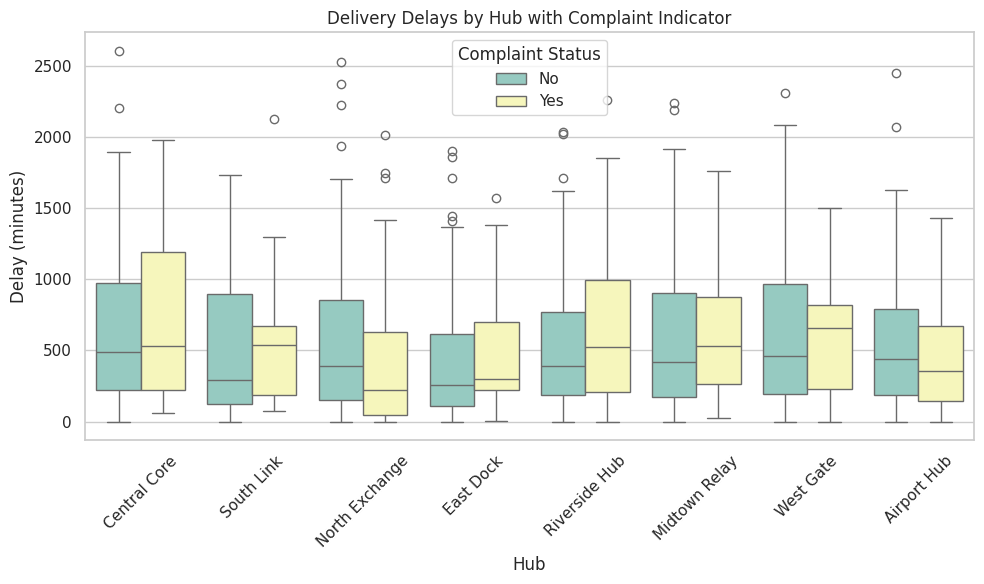

In [ ]:

master_df["has_complaint"] = master_df["has_complaint"].map({0: "No", 1: "Yes"})

plt.figure(figsize=(10,6))

sns.boxplot(
    data=master_df,
    x='hub_name',
    y='delay_minutes',
    hue='has_complaint',
    palette='Set3'
)

plt.title("Delivery Delays by Hub with Complaint Indicator")
plt.xlabel("Hub")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)

plt.legend(title="Complaint Status")

plt.tight_layout()
plt.show()

3. Top 10 Worst drivers

Identifies the top worst-performing drivers based on their delays and incidents.

/tmp/ipykernel_10780/440559550.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


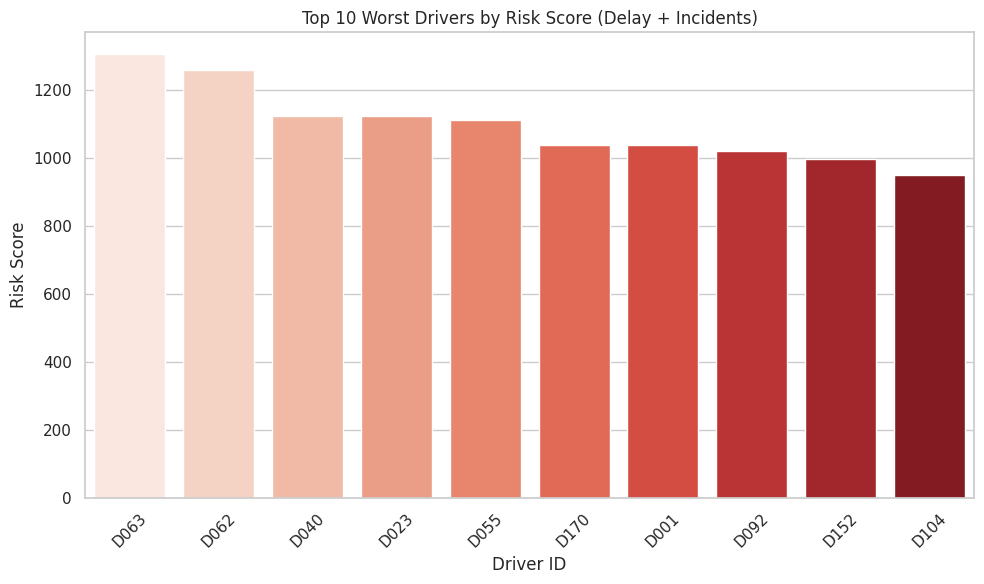

In [ ]:

driver_risk = master_df.groupby("driver_id").agg({
    "delay_minutes": "mean",
    "incident_count": "sum",
    "delivery_id": "count"
}).reset_index()

driver_risk = driver_risk.rename(columns={
    "delay_minutes": "avg_delay",
    "delivery_id": "total_deliveries"
})

driver_risk["risk_score"] = (
    driver_risk["avg_delay"] +
    driver_risk["incident_count"] * 2
)

top_worst_drivers = driver_risk.sort_values("risk_score", ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_worst_drivers,
    x="driver_id",
    y="risk_score",
    palette="Reds"
)

plt.title("Top 10 Worst Drivers by Risk Score (Delay + Incidents)")
plt.xlabel("Driver ID")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

4. Delay vs Customer Rating (Scatter + Regression)

Examines the relationship between delivery delays and customer ratings, showing overall trend.

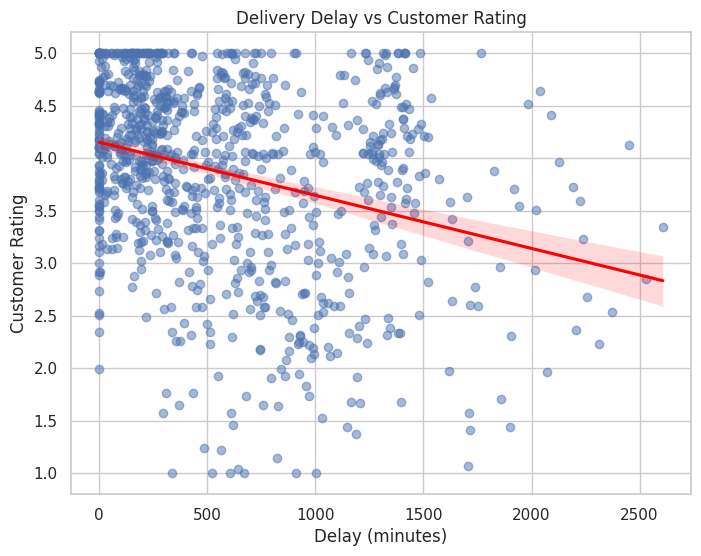

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=master_df, x='delay_minutes', y='customer_rating_post_delivery', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Delivery Delay vs Customer Rating")
plt.xlabel("Delay (minutes)")
plt.ylabel("Customer Rating")
plt.show()

5. Risk Score by Priority Level

Compares the average risk score across different priority levels.

/tmp/ipykernel_10780/1419791123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_summary, x='priority_level', y='avg_risk', palette='viridis')


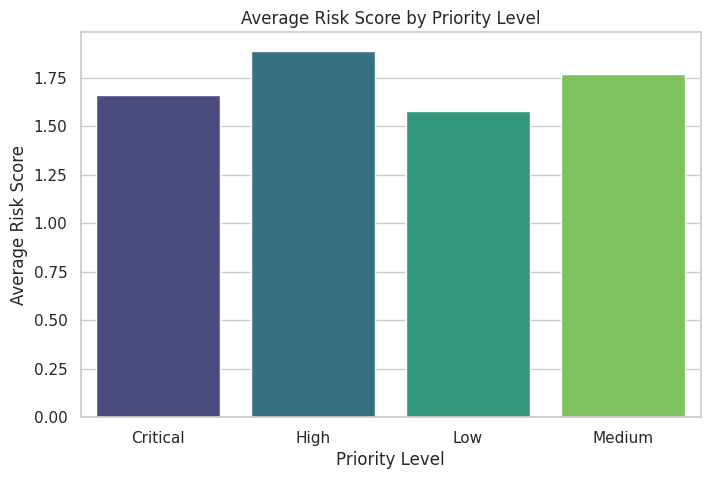

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=risk_summary, x='priority_level', y='avg_risk', palette='viridis')
plt.title("Average Risk Score by Priority Level")
plt.xlabel("Priority Level")
plt.ylabel("Average Risk Score")
plt.show()

6. Route Distance vs Fuel/Charge Cost

Shows how fuel or charging cost increases with distance, differentiated by vehicle type.

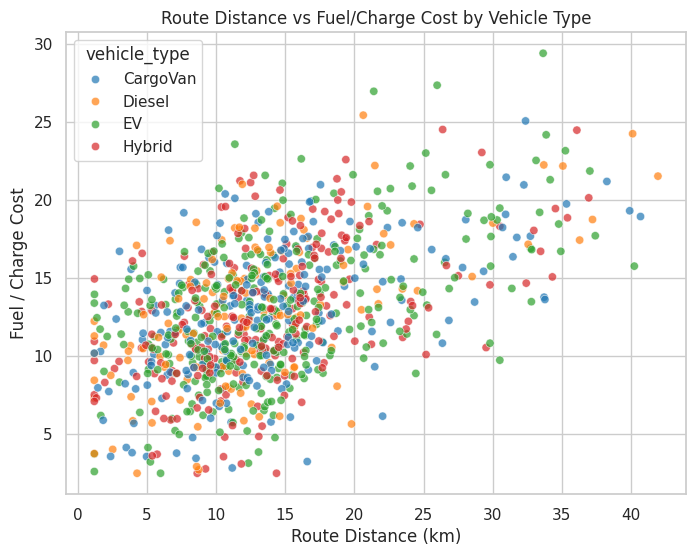

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=master_df, x='route_distance_km', y='fuel_or_charge_cost', hue='vehicle_type', palette='tab10', alpha=0.7)
plt.title("Route Distance vs Fuel/Charge Cost by Vehicle Type")
plt.xlabel("Route Distance (km)")
plt.ylabel("Fuel / Charge Cost")
plt.show()


7. Customer Age vs Risk Score

Explores how customer age is related to risk score, including a smoothed trend line.

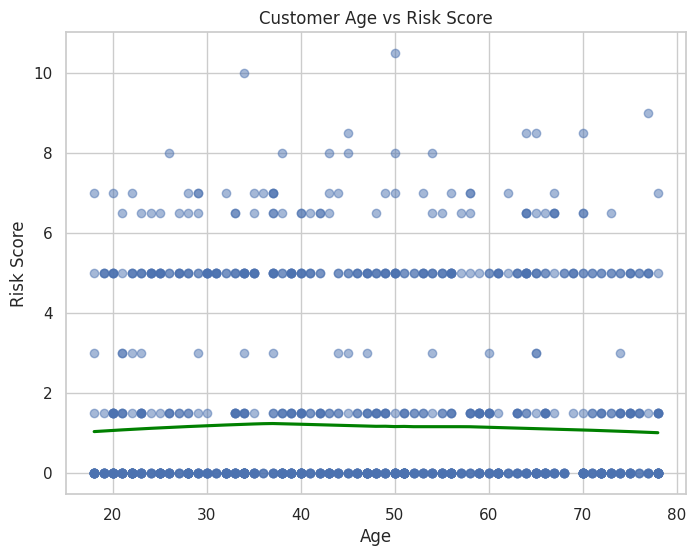

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=master_df, x='age', y='risk_score', lowess=True, scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
plt.title("Customer Age vs Risk Score")
plt.xlabel("Age")
plt.ylabel("Risk Score")
plt.show()

8. Top 10 Orders by Order Value

Highlights the highest-value orders to identify top revenue-generating transactions.

/tmp/ipykernel_10780/668205765.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_orders, x='order_id', y='order_value', palette='magma')


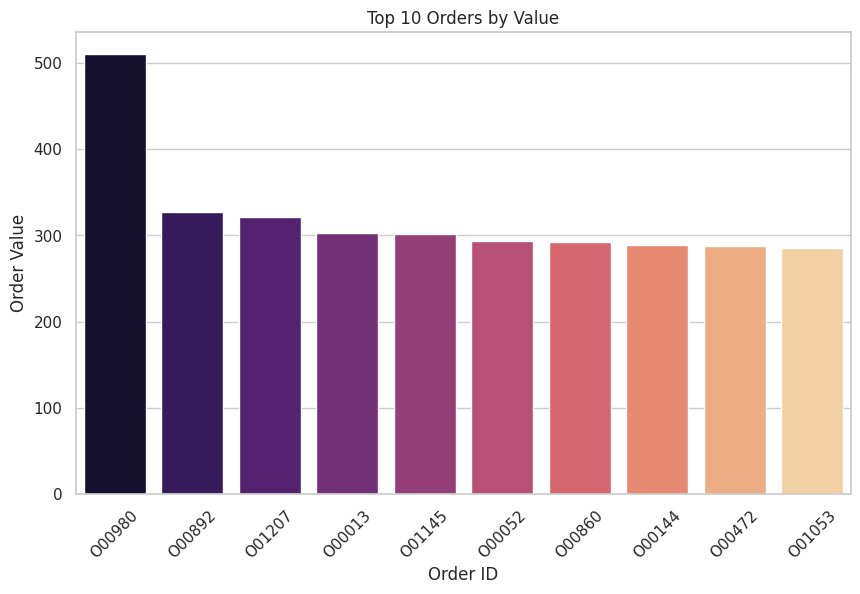

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_orders, x='order_id', y='order_value', palette='magma')
plt.title("Top 10 Orders by Value")
plt.xlabel("Order ID")
plt.ylabel("Order Value")
plt.xticks(rotation=45)
plt.show()

9. Worst Zones (Highest average delay)

Highlights worst assigned zones based on highest average delay.

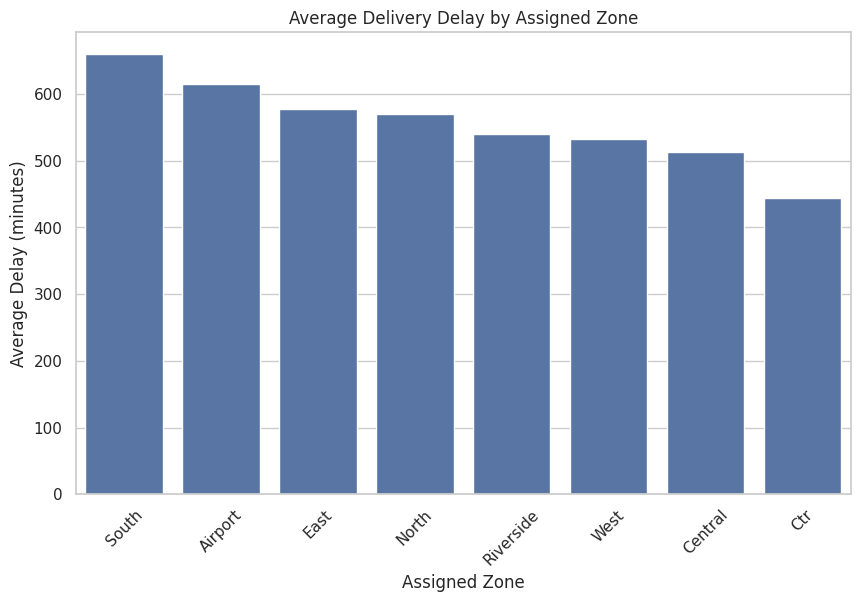

In [ ]:
zone_delay = master_df.groupby("assigned_zone")["delay_minutes"].mean().reset_index()
zone_delay["delay_minutes"] = zone_delay["delay_minutes"].round(2)
zone_delay = zone_delay.sort_values(by="delay_minutes", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=zone_delay, x="assigned_zone", y="delay_minutes")

plt.title("Average Delivery Delay by Assigned Zone")
plt.xlabel("Assigned Zone")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)

plt.show()

In [ ]:
master_df.to_csv("cleaned_dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>